In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

In [3]:
# =====================
# INPUT PARAMETERS
# =====================

Ip = 60       # Peak inflow (m3/s)

tau = 3.8     # Time base (hour)

k = 1.8       # Storage coefficient

dt = 0.05     # Time step (hour)

alpha = 2*np.pi/tau

print("Alpha =", round(alpha,3))

Alpha = 1.653


In [4]:
# time vector

t = np.arange(0, tau+dt, dt)

t

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05,
       1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 ,
       1.65, 1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15,
       2.2 , 2.25, 2.3 , 2.35, 2.4 , 2.45, 2.5 , 2.55, 2.6 , 2.65, 2.7 ,
       2.75, 2.8 , 2.85, 2.9 , 2.95, 3.  , 3.05, 3.1 , 3.15, 3.2 , 3.25,
       3.3 , 3.35, 3.4 , 3.45, 3.5 , 3.55, 3.6 , 3.65, 3.7 , 3.75, 3.8 ])

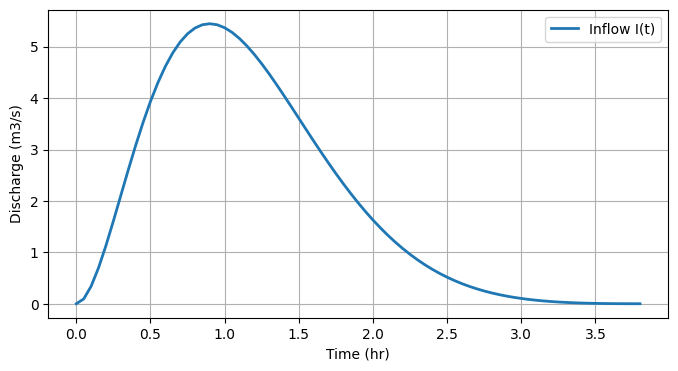

In [5]:
# =====================
# INFLOW HYDROGRAPH
# =====================

I = (Ip/2)*(1-np.cos(alpha*t))*np.exp(-k*t)


plt.figure(figsize=(8,4))

plt.plot(t,I,
         linewidth=2,
         label="Inflow I(t)")

plt.xlabel("Time (hr)")
plt.ylabel("Discharge (m3/s)")
plt.grid()

plt.legend()

plt.show()

In [6]:
# =====================
# OUTFLOW CALCULATION
# =====================


integral = cumulative_trapezoid(
    k*I*np.exp(k*t),
    t,
    initial=0
)


O = np.exp(-k*t)*integral

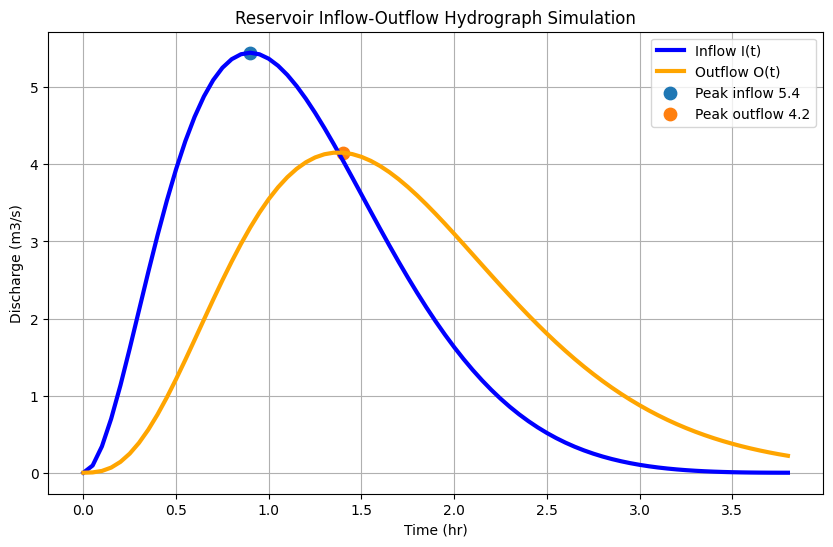

In [7]:
plt.figure(figsize=(10,6))


plt.plot(t,I,
         color="blue",
         linewidth=3,
         label="Inflow I(t)")


plt.plot(t,O,
         color="orange",
         linewidth=3,
         label="Outflow O(t)")


# maximum points

imax=np.argmax(I)
omax=np.argmax(O)


plt.scatter(
    t[imax],
    I[imax],
    s=80,
    label=f"Peak inflow {I[imax]:.1f}"
)


plt.scatter(
    t[omax],
    O[omax],
    s=80,
    label=f"Peak outflow {O[omax]:.1f}"
)


plt.xlabel("Time (hr)")
plt.ylabel("Discharge (m3/s)")

plt.title(
    "Reservoir Inflow-Outflow Hydrograph Simulation"
)


plt.grid()
plt.legend()

plt.show()